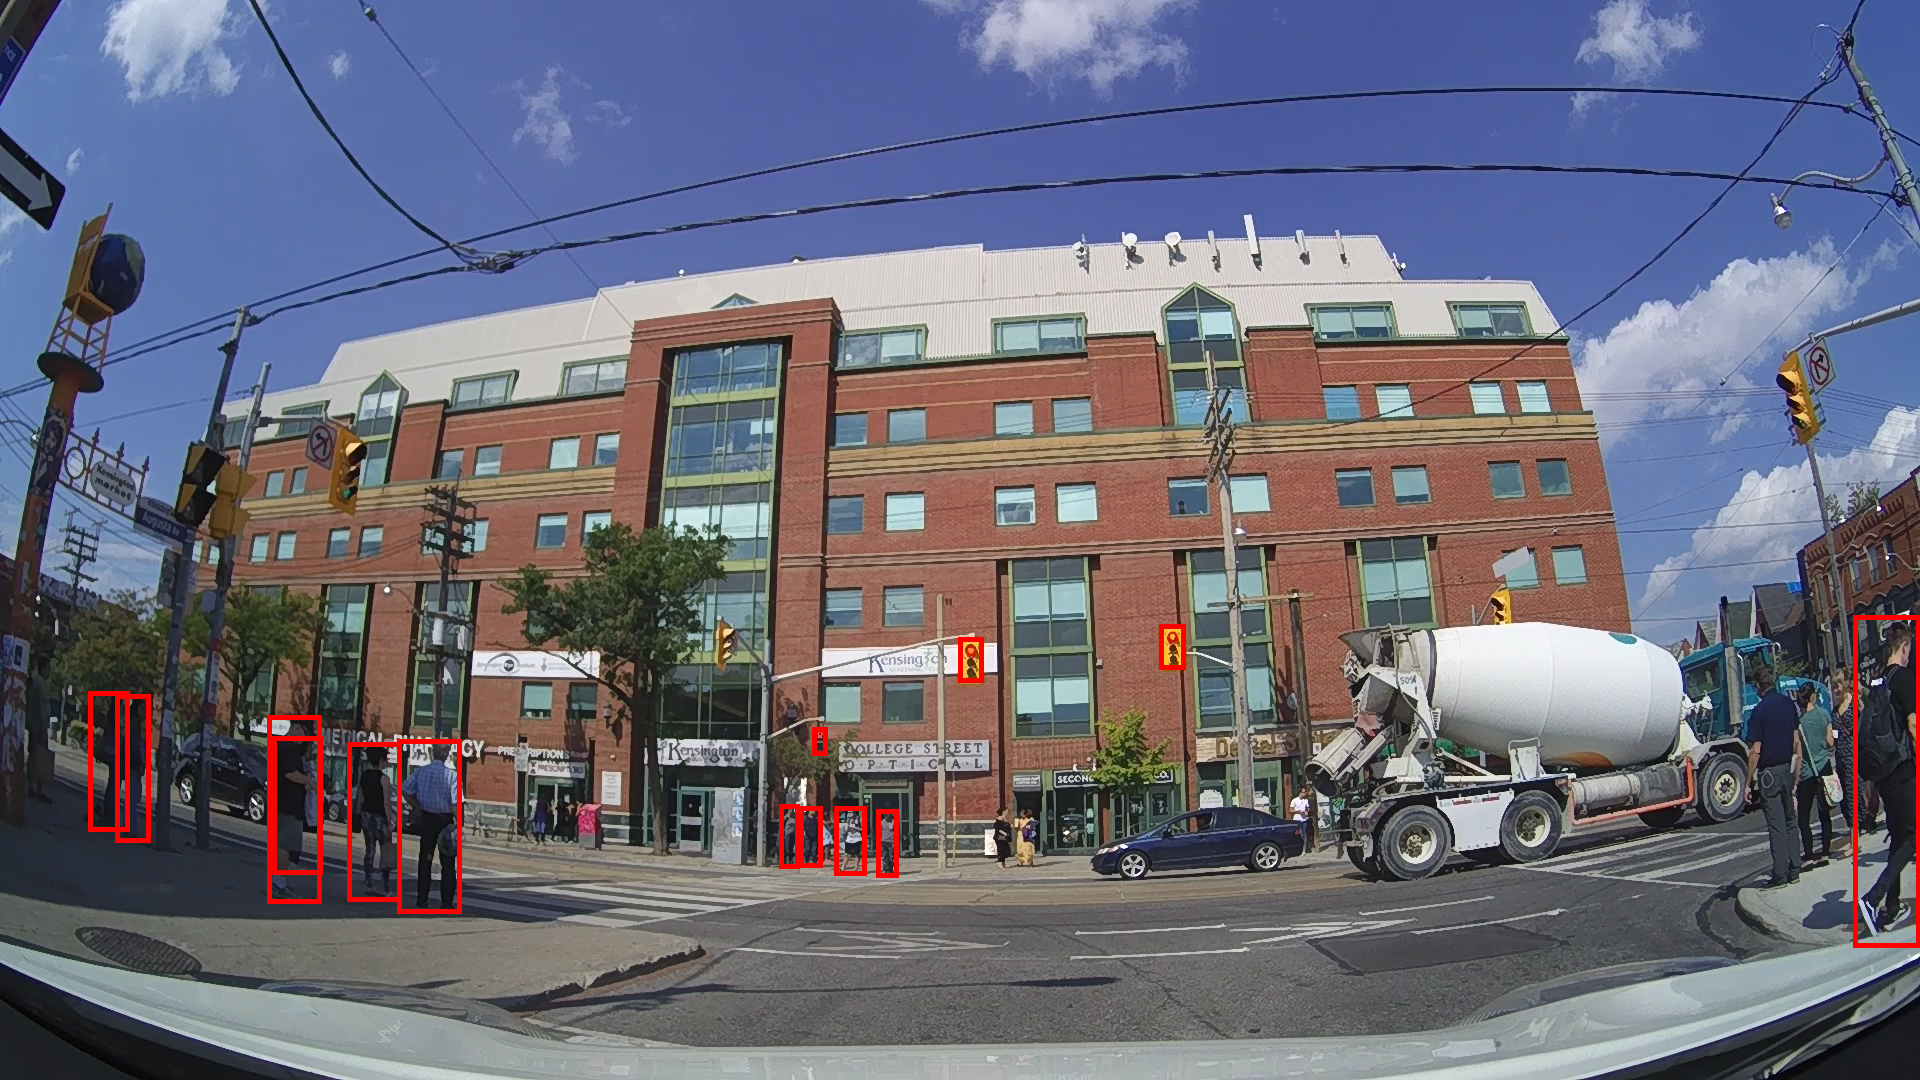

In [45]:
from PIL import Image, ImageDraw
import pandas as pd

bboxes = pd.read_csv('annotations/bboxes.csv')
img = Image.open("images/set01/video_0002/11700.png")
draw = ImageDraw.Draw(img)

boxes = bboxes.loc[(bboxes.video == 'video_0002')&(bboxes.frame == 11700), ['x1', 'y1', 'x2', 'y2']].values.tolist()
for box in boxes:
    draw.rectangle(box, outline="red", width=5)

# Display the image directly in the notebook cell
display(img)

In [46]:
box

[272.7, 736.38, 322.8, 874.05]

In [50]:
from PIL import Image

def resize_with_bbox(img, bboxes, new_height=224):
    # Load image
    old_width, old_height = img.size
    new_width = int(old_width * new_height / old_height)

    # Calculate ratios
    rx = new_width / old_width
    ry = new_height / old_height

    # Resize image
    resized_img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)

    # Scale boxes
    new_bboxes = []
    for x1, y1, x2, y2 in bboxes:
        new_bboxes.append([
            x1 * rx,
            y1 * ry,
            x2 * rx,
            y2 * ry
        ])
    
    return resized_img, new_bboxes

# Example usage
resized_image, new_boxes = resize_with_bbox(img, boxes, new_height=416)

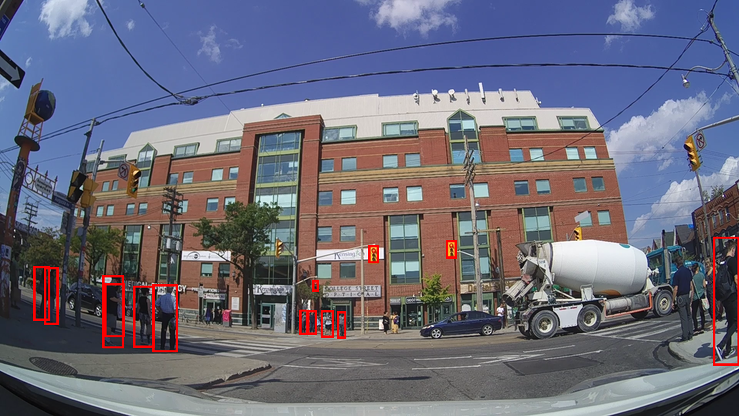

In [51]:
draw = ImageDraw.Draw(resized_image)
for box in new_boxes:
    draw.rectangle(box, outline="red", width=1)

# Display the image directly in the notebook cell
display(resized_image)

In [34]:
bboxes.groupby(['video', 'frame']).size().reset_index(name='count').sort_values('count', ascending=False).head(10)

,video,frame,count
6408,video_0002,11413,14
6695,video_0002,11700,14
6694,video_0002,11699,14
6693,video_0002,11698,14
6692,video_0002,11697,14
6691,video_0002,11696,14
6690,video_0002,11695,14
6689,video_0002,11694,14
6688,video_0002,11693,14
6687,video_0002,11692,14
